# Notebook 33: Multi-City Threshold Comparison

Tests three open methodology questions across a wider city set:
1. **P90 vs P95** percentile level
2. **Annual flat vs moving-window** threshold
3. **Absolute tropical nights** (Tmin ≥ 20°C, Tmin ≥ 25°C) vs relative P90

Uses GHSL UCDB polygons for spatial masking (no per-city shapefiles needed).  
Temperature clipped data and computed thresholds are cached to `data/cache/`.

In [2]:
import sys, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import spearmanr
import rioxarray  # noqa: F401 — registers .rio accessor

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('../heat_threshold_analysis'))
from utils.heat import compute_tx90p_threshold

In [3]:
PIPELINE_DATA = '../heat_threshold_analysis/data'
RAW_DATA      = '../data'
CACHE_DIR     = Path('../data/cache')
BASELINE      = slice('2003', '2018')
TEST_YEARS    = list(range(2003, 2021))
PERCENTILES   = [90, 95]
TN_THRESHOLDS = [20, 25]

CITIES = {
    # ── Existing cities (data already downloaded) ──────────────────────────
    'rio_de_janeiro': {
        'label': 'Rio de Janeiro', 'country': 'Brazil',
        'ucdb_aliases': ['Rio de Janeiro'],
        'tmin_path': f'{RAW_DATA}/rio_de_janeiro_tmin.nc',
    },
    'salvador': {
        'label': 'Salvador', 'country': 'Brazil',
        'ucdb_aliases': ['Salvador'],
        'tmin_path': f'{PIPELINE_DATA}/salvador_tmin.nc',
    },
    'teresina': {
        'label': 'Teresina', 'country': 'Brazil',
        'ucdb_aliases': ['Teresina'],
        'tmin_path': f'{PIPELINE_DATA}/teresina_tmin.nc',
    },
    'caceres': {
        'label': 'Cáceres', 'country': 'Brazil',
        'ucdb_aliases': ['Cáceres', 'Caceres'],
        'tmin_path': f'{PIPELINE_DATA}/caceres_tmin.nc',
    },
    'bengaluru': {
        'label': 'Bengaluru', 'country': 'India',
        'ucdb_aliases': ['Bengaluru', 'Bangalore'],
        'tmin_path': f'{RAW_DATA}/bengaluru_tmin.nc',
    },
    # ── New cities (need GEE export) ───────────────────────────────────────
    'accra':        {'label': 'Accra',         'country': 'Ghana',        'ucdb_aliases': ['Accra']},
    'lagos':        {'label': 'Lagos',         'country': 'Nigeria',      'ucdb_aliases': ['Lagos']},
    'kuala_lumpur': {'label': 'Kuala Lumpur',  'country': 'Malaysia',     'ucdb_aliases': ['Kuala Lumpur', 'Kuala lumpur']},
    'karachi':      {'label': 'Karachi',       'country': 'Pakistan',     'ucdb_aliases': ['Karachi']},
    'ekurhuleni':   {'label': 'Ekurhuleni',    'country': 'South Africa', 'ucdb_aliases': ['Ekurhuleni', 'East Rand', 'Johannesburg']},
    'krishnagiri':  {'label': 'Krishnagiri',   'country': 'India',        'ucdb_aliases': ['Krishnagiri']},
    'chennai':      {'label': 'Chennai',       'country': 'India',        'ucdb_aliases': ['Chennai', 'Madras']},
    'kalburgi':     {'label': 'Kalburgi',      'country': 'India',        'ucdb_aliases': ['Kalaburagi', 'Gulbarga', 'Kalburgi']},
    'bidar':        {'label': 'Bidar',         'country': 'India',        'ucdb_aliases': ['Bidar']},
    'vijaypura':    {'label': 'Vijaypura',     'country': 'India',        'ucdb_aliases': ['Vijayapura', 'Bijapur', 'Vijaypura']},
    'raichur':      {'label': 'Raichur',       'country': 'India',        'ucdb_aliases': ['Raichur']},
    'hospete':      {'label': 'Hospete',       'country': 'India',        'ucdb_aliases': ['Hospet', 'Hospete', 'Vijayanagara']},
    'belgavi':      {'label': 'Belgavi',       'country': 'India',        'ucdb_aliases': ['Belagavi', 'Belgaum', 'Belgavi']},
    'ballari':      {'label': 'Ballari',       'country': 'India',        'ucdb_aliases': ['Ballari', 'Bellary']},
    'mangaluru':    {'label': 'Mangaluru',     'country': 'India',        'ucdb_aliases': ['Mangaluru', 'Mangalore']},
}

CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Cache directory: {CACHE_DIR.resolve()}")
print(f"Cities to process: {len(CITIES)}")


Cache directory: /Users/martynclark/heatInsights-notebooks/data/cache
Cities to process: 20


## Section 1 — UCDB Lookup & Köppen-Geiger Zones

Match each city against GHS Urban Centre Database 2015 (R2019A).  
KG zones come from the `E_KG_NM_LST` column — no GEE call needed.  
Cities not found in UCDB (below population threshold or alternate spelling) are flagged.

In [4]:
ucdb = gpd.read_file(f'{PIPELINE_DATA}/GHS_UCDB_2015_R2019A.gpkg')
print(f"UCDB loaded: {len(ucdb)} urban centres")

def match_ucdb(ucdb, aliases, country):
    """Return the highest-population UCDB row matching any alias within country."""
    country_mask = ucdb['CTR_MN_NM'].str.lower().str.contains(country.lower(), na=False)
    candidates = ucdb[country_mask]
    for alias in aliases:
        name_mask = (
            (candidates['UC_NM_MN'].str.lower() == alias.lower()) |
            (candidates['UC_NM_LST'].str.lower().str.contains(alias.lower(), na=False))
        )
        hits = candidates[name_mask]
        if len(hits) > 0:
            return hits.loc[hits['P15'].idxmax()]
    return None

UCDB loaded: 13135 urban centres


In [5]:
city_meta = {}
rows = []
for slug, cfg in CITIES.items():
    match = match_ucdb(ucdb, cfg['ucdb_aliases'], cfg['country'])
    if match is not None:
        city_meta[slug] = {
            **cfg,
            'geometry': match.geometry,
            'kg_zone':  match['E_KG_NM_LST'],
            'pop_2015': int(match['P15']),
            'lat':      float(match['GCPNT_LAT']),
            'lon':      float(match['GCPNT_LON']),
        }
        rows.append({'city': cfg['label'], 'country': cfg['country'],
                     'ucdb_matched': 'Yes', 'kg_zone': match['E_KG_NM_LST'],
                     'pop_2015': int(match['P15'])})
    else:
        city_meta[slug] = {**cfg, 'geometry': None, 'kg_zone': None,
                           'pop_2015': None, 'lat': None, 'lon': None}
        rows.append({'city': cfg['label'], 'country': cfg['country'],
                     'ucdb_matched': 'NO MATCH', 'kg_zone': '\u2014', 'pop_2015': None})

match_df = pd.DataFrame(rows)
print(match_df.to_string(index=False))

          city      country ucdb_matched                                          kg_zone   pop_2015
Rio de Janeiro       Brazil          Yes                Tropical savannah with dry winter  9798104.0
      Salvador       Brazil          Yes                             Tropical rain forest  3030495.0
      Teresina       Brazil          Yes                Tropical savannah with dry winter   894356.0
       Cáceres       Brazil          Yes                Tropical savannah with dry winter    65883.0
     Bengaluru        India          Yes                Tropical savannah with dry winter 10631615.0
         Accra        Ghana          Yes                Tropical savannah with dry winter  4412617.0
         Lagos      Nigeria          Yes                Tropical savannah with dry winter 11575042.0
  Kuala Lumpur     Malaysia          Yes                             Tropical rain forest  6339649.0
       Karachi     Pakistan          Yes                     Desert (arid), and  Hot arid 1

## Section 2 — Data Availability

Raw GSHTD Tmin NetCDF files are expected at `heat_threshold_analysis/data/{slug}_tmin.nc`.  
Cities without a local file need a GEE export (see stub below) before analysis can run.

In [6]:
for slug, meta in city_meta.items():
    # Use explicit tmin_path if set in config; otherwise try standard locations
    override = meta.get('tmin_path')
    if override and Path(override).exists():
        meta['raw_path'] = Path(override)
    else:
        candidates = [
            Path(f'{PIPELINE_DATA}/{slug}_tmin.nc'),
            Path(f'{RAW_DATA}/{slug}_tmin.nc'),
        ]
        found = next((p for p in candidates if p.exists()), None)
        meta['raw_path'] = found

avail_df = pd.DataFrame([
    {'city': m['label'], 'ucdb_matched': 'Yes' if m['geometry'] is not None else 'No',
     'tmin_file': str(m['raw_path'].name) if m['raw_path'] else 'MISSING'}
    for m in city_meta.values()
])
print(avail_df.to_string(index=False))
missing = [m['label'] for m in city_meta.values() if not m['raw_path']]
if missing:
    print(f"\n{len(missing)} cities need GEE export: {', '.join(missing)}")


          city ucdb_matched              tmin_file
Rio de Janeiro          Yes rio_de_janeiro_tmin.nc
      Salvador          Yes       salvador_tmin.nc
      Teresina          Yes       teresina_tmin.nc
       Cáceres          Yes        caceres_tmin.nc
     Bengaluru          Yes      bengaluru_tmin.nc
         Accra          Yes          accra_tmin.nc
         Lagos          Yes          lagos_tmin.nc
  Kuala Lumpur          Yes   kuala_lumpur_tmin.nc
       Karachi          Yes        karachi_tmin.nc
    Ekurhuleni          Yes     ekurhuleni_tmin.nc
   Krishnagiri          Yes    krishnagiri_tmin.nc
       Chennai          Yes        chennai_tmin.nc
      Kalburgi          Yes       kalburgi_tmin.nc
         Bidar          Yes          bidar_tmin.nc
     Vijaypura          Yes      vijaypura_tmin.nc
       Raichur          Yes        raichur_tmin.nc
       Hospete           No                MISSING
       Belgavi          Yes        belgavi_tmin.nc
       Ballari          Yes    

## Section 2b — GEE Export Template

Run the JavaScript below in the [GEE Code Editor](https://code.earthengine.google.com/) for each missing city.  
Replace `CITY_NAME`, `LON_MIN`, `LAT_MIN`, `LON_MAX`, `LAT_MAX` with values from the UCDB row.  
Exports land-only daily Tmin (°C) clipped to city bounding box + 0.1° buffer.

In [7]:
gee_template = """
// \u2500\u2500 GEE Export: GSHTD Daily Tmin \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
// Replace placeholders before running.

var CITY_NAME = 'accra';       // used as filename prefix
var bbox = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX]);

var gshtd = ee.ImageCollection('projects/sat-io/open-datasets/GSHTD/TMIN')
    .filterBounds(bbox)
    .filterDate('2003-01-01', '2021-01-01');

var tmin_stack = gshtd.map(function(img) {
  return img.divide(10).rename('tmin')
            .set('system:time_start', img.get('system:time_start'));
});

Export.image.toDrive({
  image:        tmin_stack.toBands(),
  description:  CITY_NAME + '_tmin_2003_2020',
  folder:       'GSHTD_exports',
  fileNamePrefix: CITY_NAME + '_tmin',
  region:       bbox,
  scale:        1000,
  crs:          'EPSG:4326',
  maxPixels:    1e13,
  fileFormat:   'GeoTIFF'
});
// \u2500\u2500 After export, convert GeoTIFF stack to NetCDF using gdal_translate or xarray \u2500\u2500
"""
print(gee_template)


// ── GEE Export: GSHTD Daily Tmin ──────────────────────────────────────────
// Replace placeholders before running.

var CITY_NAME = 'accra';       // used as filename prefix
var bbox = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX]);

var gshtd = ee.ImageCollection('projects/sat-io/open-datasets/GSHTD/TMIN')
    .filterBounds(bbox)
    .filterDate('2003-01-01', '2021-01-01');

var tmin_stack = gshtd.map(function(img) {
  return img.divide(10).rename('tmin')
            .set('system:time_start', img.get('system:time_start'));
});

Export.image.toDrive({
  image:        tmin_stack.toBands(),
  description:  CITY_NAME + '_tmin_2003_2020',
  folder:       'GSHTD_exports',
  fileNamePrefix: CITY_NAME + '_tmin',
  region:       bbox,
  scale:        1000,
  crs:          'EPSG:4326',
  maxPixels:    1e13,
  fileFormat:   'GeoTIFF'
});
// ── After export, convert GeoTIFF stack to NetCDF using gdal_translate or xarray ──



## Section 3 — Load & Clip Tmin with Caching

Each city's Tmin is clipped to its UCDB polygon and saved to `data/cache/{slug}_tmin_clipped.nc`.  
Subsequent runs load from cache — preserving the full 2003–2020 series for flexible xclim use.

In [8]:
def load_clipped_tmin(slug, meta, cache_dir):
    """Load Tmin clipped to UCDB polygon; cache result."""
    cache_path = cache_dir / f"{slug}_tmin_clipped.nc"
    if cache_path.exists():
        ds = xr.open_dataset(cache_path, chunks='auto')
        if 'tmin' in ds:
            print(f"  [{meta['label']}] cache hit — loading clipped Tmin")
            return ds['tmin']
        # Corrupt/partial write — delete and recompute
        print(f"  [{meta['label']}] corrupt cache, recomputing...")
        cache_path.unlink()

    if meta['raw_path'] is None:
        print(f"  [{meta['label']}] SKIP — no raw file")
        return None
    if meta['geometry'] is None:
        print(f"  [{meta['label']}] SKIP — no UCDB geometry")
        return None

    print(f"  [{meta['label']}] clipping to UCDB polygon and caching...")
    ds = xr.open_dataset(meta['raw_path'])
    da = ds['tmin']
    da = (da
          .rio.set_spatial_dims(x_dim='lon', y_dim='lat')
          .rio.write_crs('EPSG:4326'))
    clipped = da.rio.clip([meta['geometry'].__geo_interface__], crs=4326, drop=True)
    clipped.name = 'tmin'
    clipped.attrs.pop('grid_mapping', None)
    clipped.to_netcdf(cache_path)
    print(f"    saved → {cache_path}")
    return clipped.chunk('auto')


tmin_data = {}
for slug, meta in city_meta.items():
    tmin_data[slug] = load_clipped_tmin(slug, meta, CACHE_DIR)

  [Rio de Janeiro] cache hit — loading clipped Tmin
  [Salvador] cache hit — loading clipped Tmin
  [Teresina] cache hit — loading clipped Tmin
  [Cáceres] cache hit — loading clipped Tmin
  [Bengaluru] cache hit — loading clipped Tmin
  [Accra] cache hit — loading clipped Tmin
  [Lagos] cache hit — loading clipped Tmin
  [Kuala Lumpur] cache hit — loading clipped Tmin
  [Karachi] cache hit — loading clipped Tmin
  [Ekurhuleni] cache hit — loading clipped Tmin
  [Krishnagiri] cache hit — loading clipped Tmin
  [Chennai] cache hit — loading clipped Tmin
  [Kalburgi] clipping to UCDB polygon and caching...
    saved → ../data/cache/kalburgi_tmin_clipped.nc
  [Bidar] clipping to UCDB polygon and caching...
    saved → ../data/cache/bidar_tmin_clipped.nc
  [Vijaypura] clipping to UCDB polygon and caching...
    saved → ../data/cache/vijaypura_tmin_clipped.nc
  [Raichur] clipping to UCDB polygon and caching...
    saved → ../data/cache/raichur_tmin_clipped.nc
  [Hospete] SKIP — no raw file


## Section 4 — Compute Thresholds

For each city, compute **Citywide-A** versions of all threshold variants:

| Variant | Method |
|---|---|
| `annual_p90` | P90 scalar from all urban pixels × all baseline days |
| `annual_p95` | P95 scalar (same method) |
| `mw_p90` | Mean of per-pixel MW P90 → dayofyear curve; cached |
| `mw_p95` | Mean of per-pixel MW P95 → dayofyear curve; cached |

Absolute thresholds (20°C, 25°C) need no pre-computation.

In [9]:
def _citywide_percentile_curve(tmin_baseline, window=5, per=90):
    """Citywide pooled P-th percentile per day-of-year.

    Replicates xclim.core.calendar.percentile_doy's internal pipeline but folds
    all spatial dims into the reduce axis alongside (year, window), so xclim's
    own calc_perc kernel pools pixels + years + window in a single vectorised
    C call. No per-pixel normalisation; no cftime object loop.

    Returns a (dayofyear,) DataArray — one citywide threshold value per calendar day.
    """
    import pandas as pd
    from xclim.core.utils import calc_perc
    from xclim.core.calendar import adjust_doy_calendar

    da = tmin_baseline
    spatial_dims = tuple(d for d in da.dims if d != "time")

    # 1. Rolling window along time — matches percentile_doy exactly
    rr = da.rolling(min_periods=1, center=True, time=window).construct("window")

    # 2. Split time → (year, dayofyear) MultiIndex then unstack
    midx = pd.MultiIndex.from_arrays(
        (rr.time.dt.year.values, rr.time.dt.dayofyear.values),
        names=("year", "dayofyear"),
    )
    crd = xr.Coordinates.from_pandas_multiindex(midx, "time")
    rr = rr.drop_vars("time").assign_coords(crd).unstack("time")
    # shape: (year, dayofyear, *spatial_dims, window)

    # 3. Pool year + window + ALL spatial dims into one reduce axis
    #    (percentile_doy stacks only (year, window), keeping spatial separate —
    #    that's the only difference)
    rrr = rr.stack(stack_dim=("year", "window", *spatial_dims))

    # 4. Apply xclim's own quantile kernel across the pooled axis
    p = xr.apply_ufunc(
        calc_perc,
        rrr,
        input_core_dims=[["stack_dim"]],
        output_core_dims=[["percentiles"]],
        keep_attrs=True,
        kwargs={"percentiles": [float(per)], "alpha": 1/3, "beta": 1/3, "copy": False},
        dask="parallelized",
        output_dtypes=[rrr.dtype],
        dask_gufunc_kwargs={"output_sizes": {"percentiles": 1}},
    )
    p = p.squeeze("percentiles", drop=True)

    # 5. Trim doy 366 if present (leap-year artefact), matching percentile_doy
    if int(p.dayofyear.max()) == 366:
        p = adjust_doy_calendar(p.sel(dayofyear=(p.dayofyear < 366)), da)

    p.attrs.update({"units": da.attrs.get("units", "degC"), "percentile": float(per), "window": window})
    return p


def get_annual_threshold(tmin_baseline, perc):
    """Annual citywide P-th scalar: pools all valid pixels × all baseline days."""
    da_loc = tmin_baseline.stack(location=('lat', 'lon')).dropna('location', how='all')
    return float(np.nanpercentile(da_loc.values, perc))


def get_mw_threshold(slug, tmin_baseline, perc, cache_dir):
    """Citywide MW threshold curve (dayofyear,); pools raw values across all pixels via xclim."""
    cache_path = cache_dir / f"{slug}_tn{perc}p_mw_citywide_curve.nc"
    if cache_path.exists():
        return xr.open_dataarray(cache_path)
    print(f"    computing citywide MW P{perc} for {slug}...")
    thresh = _citywide_percentile_curve(tmin_baseline, window=5, per=perc)
    thresh.to_netcdf(cache_path)
    return thresh  # shape (dayofyear,)


city_thresholds = {}
for slug, tmin in tmin_data.items():
    if tmin is None:
        continue
    print(f"[{city_meta[slug]['label']}]")
    baseline = tmin.sel(time=BASELINE).load()
    thresholds = {}
    for perc in PERCENTILES:
        thresholds[f'annual_p{perc}'] = get_annual_threshold(baseline, perc)
        thresholds[f'mw_p{perc}_curve'] = get_mw_threshold(slug, baseline, perc, CACHE_DIR)
    city_thresholds[slug] = thresholds
    print(f"  annual P90={thresholds['annual_p90']:.2f}\u00b0C  P95={thresholds['annual_p95']:.2f}\u00b0C")

[Rio de Janeiro]
  annual P90=23.30°C  P95=24.20°C
[Salvador]
  annual P90=24.40°C  P95=25.00°C
[Teresina]
  annual P90=25.20°C  P95=25.60°C
[Cáceres]
  annual P90=24.30°C  P95=24.80°C
[Bengaluru]
  annual P90=22.30°C  P95=23.10°C
[Accra]
  annual P90=25.60°C  P95=26.00°C
[Lagos]
  annual P90=25.70°C  P95=26.10°C
[Kuala Lumpur]
  annual P90=24.80°C  P95=25.10°C
[Karachi]
  annual P90=27.40°C  P95=28.10°C
[Ekurhuleni]
    computing citywide MW P90 for ekurhuleni...
    computing citywide MW P95 for ekurhuleni...
  annual P90=15.90°C  P95=16.60°C
[Krishnagiri]
    computing citywide MW P90 for krishnagiri...
    computing citywide MW P95 for krishnagiri...
  annual P90=24.40°C  P95=25.10°C
[Chennai]
    computing citywide MW P90 for chennai...
    computing citywide MW P95 for chennai...
  annual P90=27.70°C  P95=28.30°C
[Kalburgi]
    computing citywide MW P90 for kalburgi...
    computing citywide MW P95 for kalburgi...
  annual P90=25.50°C  P95=26.50°C
[Bidar]
    computing citywide M

## Section 5 — Count Exceedance Days

For each city × year × method, count mean heat days (mean across urban pixels, sum across days).  
Results cached per city as parquet; reload on subsequent runs.

In [10]:
def count_heat_days(tmin_year, method, thresh_scalar=None, thresh_curve=None, tn_thresh=None):
    """Mean heat days over urban pixels for one city-year under one threshold method."""
    if method.startswith('annual'):
        exc = (tmin_year > thresh_scalar).sum(dim='time')
    elif method.startswith('mw'):
        doy = xr.DataArray(
            tmin_year.time.dt.dayofyear.values,
            dims='time', coords={'time': tmin_year.time}
        )
        daily_thresh = thresh_curve.sel(dayofyear=doy)
        exc = (tmin_year > daily_thresh).sum(dim='time')
    else:  # tn20 / tn25
        exc = (tmin_year > tn_thresh).sum(dim='time')
    return float(exc.mean())


all_results = []
for slug, tmin in tmin_data.items():
    if tmin is None or slug not in city_thresholds:
        continue

    cache_path = CACHE_DIR / f"{slug}_exceedance_counts.parquet"
    if cache_path.exists():
        print(f"[{city_meta[slug]['label']}] loading cached exceedance counts")
        df = pd.read_parquet(cache_path)
        all_results.append(df)
        continue

    print(f"[{city_meta[slug]['label']}] computing exceedance days...")
    thresholds = city_thresholds[slug]
    rows = []
    for year in TEST_YEARS:
        tmin_yr = tmin.sel(time=str(year)).load()
        for perc in PERCENTILES:
            rows.append({
                'slug': slug, 'city': city_meta[slug]['label'],
                'country': city_meta[slug]['country'],
                'kg_zone': city_meta[slug]['kg_zone'],
                'year': year, 'method': f'annual_p{perc}',
                'mean_heat_days': count_heat_days(
                    tmin_yr, f'annual_p{perc}',
                    thresh_scalar=thresholds[f'annual_p{perc}'])
            })
            rows.append({
                'slug': slug, 'city': city_meta[slug]['label'],
                'country': city_meta[slug]['country'],
                'kg_zone': city_meta[slug]['kg_zone'],
                'year': year, 'method': f'mw_p{perc}',
                'mean_heat_days': count_heat_days(
                    tmin_yr, f'mw_p{perc}',
                    thresh_curve=thresholds[f'mw_p{perc}_curve'])
            })
        for tn in TN_THRESHOLDS:
            rows.append({
                'slug': slug, 'city': city_meta[slug]['label'],
                'country': city_meta[slug]['country'],
                'kg_zone': city_meta[slug]['kg_zone'],
                'year': year, 'method': f'tn{tn}',
                'mean_heat_days': count_heat_days(tmin_yr, f'tn{tn}', tn_thresh=tn)
            })

    df = pd.DataFrame(rows)
    df.to_parquet(cache_path, index=False)
    all_results.append(df)
    print(f"  saved \u2192 {cache_path}")

results = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
print(f"\nTotal rows: {len(results)}")

[Rio de Janeiro] computing exceedance days...
  saved → ../data/cache/rio_de_janeiro_exceedance_counts.parquet
[Salvador] computing exceedance days...
  saved → ../data/cache/salvador_exceedance_counts.parquet
[Teresina] computing exceedance days...
  saved → ../data/cache/teresina_exceedance_counts.parquet
[Cáceres] computing exceedance days...
  saved → ../data/cache/caceres_exceedance_counts.parquet
[Bengaluru] computing exceedance days...
  saved → ../data/cache/bengaluru_exceedance_counts.parquet
[Accra] computing exceedance days...
  saved → ../data/cache/accra_exceedance_counts.parquet
[Lagos] computing exceedance days...
  saved → ../data/cache/lagos_exceedance_counts.parquet
[Kuala Lumpur] computing exceedance days...
  saved → ../data/cache/kuala_lumpur_exceedance_counts.parquet
[Karachi] computing exceedance days...
  saved → ../data/cache/karachi_exceedance_counts.parquet
[Ekurhuleni] computing exceedance days...
  saved → ../data/cache/ekurhuleni_exceedance_counts.parquet


## Section 6 — Comparison

### 6a. Spearman \u03c1 between methods (cross-city rankings)

For each test year, rank cities by mean heat days under each method and compute pairwise \u03c1.  
High \u03c1 = methods agree on which cities are hottest; low \u03c1 = methods reorder cities.

Spearman ρ matrix — 2019 (n=18 cities)

            annual_p90  annual_p95  mw_p90  mw_p95   tn20   tn25
annual_p90       1.000       0.884   0.969   0.938  0.036  0.342
annual_p95       0.884       1.000   0.899   0.928 -0.032  0.566
mw_p90           0.969       0.899   1.000   0.948  0.040  0.386
mw_p95           0.938       0.928   0.948   1.000 -0.040  0.424
tn20             0.036      -0.032   0.040  -0.040  1.000  0.371
tn25             0.342       0.566   0.386   0.424  0.371  1.000


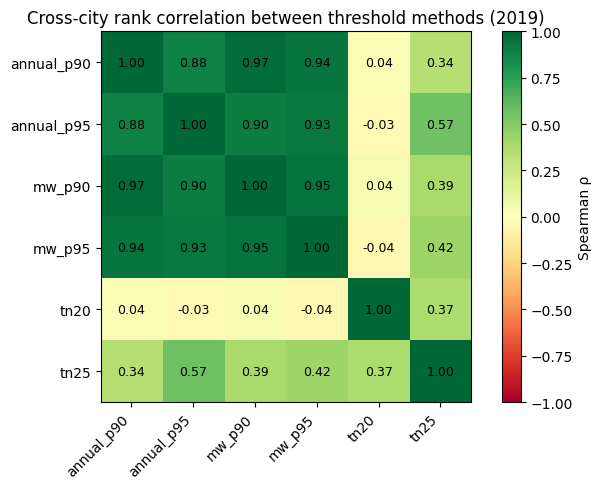

In [11]:
REFERENCE_YEAR = 2019
methods = ['annual_p90', 'annual_p95', 'mw_p90', 'mw_p95', 'tn20', 'tn25']

ref = results[results['year'] == REFERENCE_YEAR]
pivot = ref.pivot(index='city', columns='method', values='mean_heat_days').dropna()

rho_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m1 in methods:
    for m2 in methods:
        if m1 in pivot.columns and m2 in pivot.columns:
            rho, _ = spearmanr(pivot[m1], pivot[m2])
            rho_matrix.loc[m1, m2] = round(rho, 3)

print(f"Spearman \u03c1 matrix \u2014 {REFERENCE_YEAR} (n={len(pivot)} cities)\n")
print(rho_matrix.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(rho_matrix.values.astype(float), vmin=-1, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(len(methods))); ax.set_yticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.set_yticklabels(methods)
for i in range(len(methods)):
    for j in range(len(methods)):
        val = rho_matrix.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Spearman \u03c1')
ax.set_title(f'Cross-city rank correlation between threshold methods ({REFERENCE_YEAR})')
plt.tight_layout()
plt.show()

### 6b. Annual vs Moving-Window divergence by city

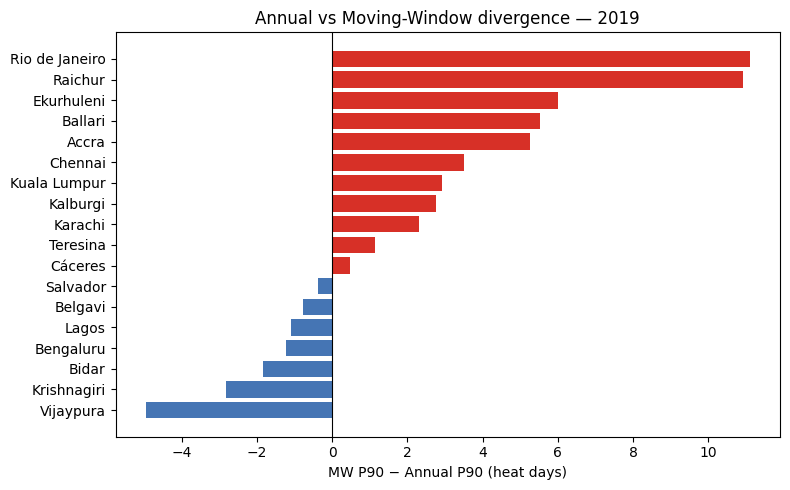

          city                                          kg_zone  annual_p90_days  mw_p90_days  delta_days
     Vijaypura                Steppe (semi-arid), and  Hot arid        29.727273    24.772727   -4.954545
   Krishnagiri                Tropical savannah with dry winter        26.890625    24.078125   -2.812500
         Bidar                Tropical savannah with dry winter        24.593750    22.750000   -1.843750
     Bengaluru                Tropical savannah with dry winter        12.710961    11.476727   -1.234234
         Lagos                Tropical savannah with dry winter        12.466849    11.363562   -1.103288
       Belgavi                Tropical savannah with dry winter        19.288770    18.524064   -0.764706
      Salvador                             Tropical rain forest        23.029221    22.660714   -0.368506
       Cáceres                Tropical savannah with dry winter        14.208333    14.687500    0.479167
      Teresina                Tropical savanna

In [12]:
div_rows = []
for city in pivot.index:
    row = pivot.loc[city]
    if 'annual_p90' in row and 'mw_p90' in row:
        div_rows.append({
            'city': city,
            'kg_zone': results[results['city'] == city]['kg_zone'].iloc[0],
            'annual_p90_days': row['annual_p90'],
            'mw_p90_days':     row['mw_p90'],
            'delta_days':      row['mw_p90'] - row['annual_p90'],
        })

div_df = pd.DataFrame(div_rows).sort_values('delta_days')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d73027' if d > 0 else '#4575b4' for d in div_df['delta_days']]
ax.barh(div_df['city'], div_df['delta_days'], color=colors)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('MW P90 \u2212 Annual P90 (heat days)')
ax.set_title(f'Annual vs Moving-Window divergence \u2014 {REFERENCE_YEAR}')
plt.tight_layout()
plt.show()
print(div_df[['city', 'kg_zone', 'annual_p90_days', 'mw_p90_days', 'delta_days']].to_string(index=False))

### 6c. Relative (P90) vs Absolute (TN25) divergence

Do absolute thresholds reorder cities relative to P90?  
Cities where the two methods disagree most are the most sensitive to threshold choice.

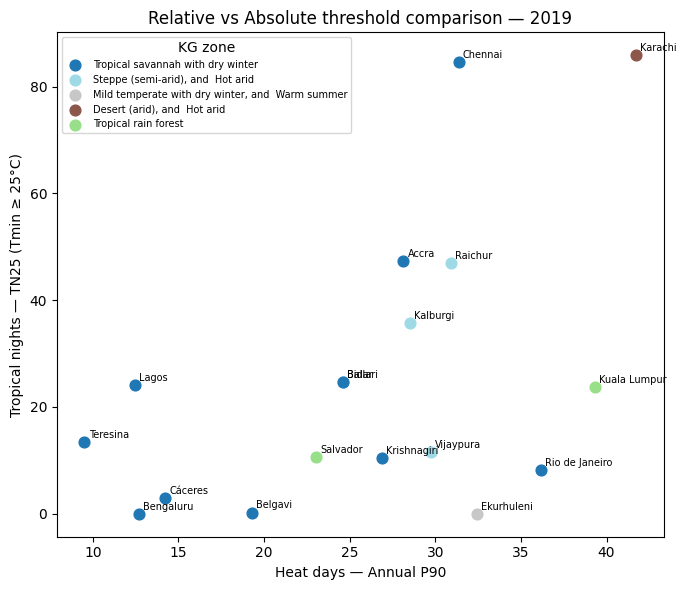

Cities with largest rank shift (Annual P90 vs TN25):
city
Ekurhuleni        13.5
Rio de Janeiro    11.0
Lagos              9.0
Teresina           8.0
Kuala Lumpur       7.0
Accra              6.0
Ballari            5.0
Bidar              5.0
Vijaypura          4.0
Kalburgi           3.0


In [13]:
if 'annual_p90' in pivot.columns and 'tn25' in pivot.columns:
    fig, ax = plt.subplots(figsize=(7, 6))
    kg_zones = results['kg_zone'].dropna().unique()
    cmap = cm.get_cmap('tab20', len(kg_zones))
    zone_color = {z: cmap(i) for i, z in enumerate(kg_zones)}

    for city in pivot.index:
        kg = results[results['city'] == city]['kg_zone'].iloc[0]
        color = zone_color.get(kg, 'grey')
        ax.scatter(pivot.loc[city, 'annual_p90'], pivot.loc[city, 'tn25'],
                   color=color, s=60, label=kg if kg not in ax.get_legend_handles_labels()[1] else '')
        ax.annotate(city, (pivot.loc[city, 'annual_p90'], pivot.loc[city, 'tn25']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel('Heat days \u2014 Annual P90')
    ax.set_ylabel('Tropical nights \u2014 TN25 (Tmin \u2265 25\u00b0C)')
    ax.set_title(f'Relative vs Absolute threshold comparison \u2014 {REFERENCE_YEAR}')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=7, loc='upper left', title='KG zone')
    plt.tight_layout()
    plt.show()

    rank_p90 = pivot['annual_p90'].rank(ascending=False)
    rank_tn25 = pivot['tn25'].rank(ascending=False)
    rank_diff = (rank_p90 - rank_tn25).abs().sort_values(ascending=False)
    print("Cities with largest rank shift (Annual P90 vs TN25):")
    print(rank_diff.head(10).to_string())

## Section 7 — Summary Table

One row per city: KG zone, P90 threshold value, mean heat days under all 6 methods.  
Exported to `data/cache/nb33_summary.csv`.

In [14]:
if not results.empty:
    summary_rows = []
    for slug, meta in city_meta.items():
        if tmin_data.get(slug) is None or slug not in city_thresholds:
            continue
        city_label = meta['label']
        ref_rows = results[(results['city'] == city_label) & (results['year'] == REFERENCE_YEAR)]
        method_days = ref_rows.set_index('method')['mean_heat_days'].to_dict()
        summary_rows.append({
            'city':           city_label,
            'country':        meta['country'],
            'kg_zone':        meta['kg_zone'],
            'pop_2015':       meta['pop_2015'],
            'p90_threshold':  round(city_thresholds[slug]['annual_p90'], 2),
            'p95_threshold':  round(city_thresholds[slug]['annual_p95'], 2),
            **{f'days_{m}': round(method_days.get(m, np.nan), 1) for m in methods}
        })

    summary_df = pd.DataFrame(summary_rows).sort_values('kg_zone')
    out_path = CACHE_DIR / 'nb33_summary.csv'
    summary_df.to_csv(out_path, index=False)
    print(f"Summary saved \u2192 {out_path}\n")
    display(summary_df)

Summary saved → ../data/cache/nb33_summary.csv



,city,country,kg_zone,pop_2015,p90_threshold,p95_threshold,days_annual_p90,days_annual_p95,days_mw_p90,days_mw_p95,days_tn20,days_tn25
8,Karachi,Pakistan,"Desert (arid), and Hot arid",13150694,27.4,28.1,41.7,26.2,44.0,27.1,128.2,85.9
9,Ekurhuleni,South Africa,"Mild temperate with dry winter, and Warm summer",6516134,15.9,16.6,32.4,18.1,38.4,22.9,0.1,0.0
15,Raichur,India,"Steppe (semi-arid), and Hot arid",295383,25.8,26.8,30.9,19.4,41.8,16.9,166.1,47.0
14,Vijaypura,India,"Steppe (semi-arid), and Hot arid",549613,23.9,24.8,29.7,13.4,24.8,12.8,139.9,11.5
12,Kalburgi,India,"Steppe (semi-arid), and Hot arid",753485,25.5,26.5,28.5,17.8,31.3,13.1,148.7,35.8
17,Ballari,India,"Steppe (semi-arid), and Hot arid",585395,25.0,25.8,24.6,13.5,30.1,11.2,127.4,24.6
7,Kuala Lumpur,Malaysia,Tropical rain forest,6339649,24.8,25.1,39.3,16.5,42.3,21.3,186.4,23.7
1,Salvador,Brazil,Tropical rain forest,3030495,24.4,25.0,23.0,10.7,22.7,10.8,140.1,10.7
6,Lagos,Nigeria,Tropical savannah with dry winter,11575042,25.7,26.1,12.5,6.5,11.4,5.7,111.6,24.1
16,Belgavi,India,Tropical savannah with dry winter,857169,21.7,22.4,19.3,10.4,18.5,10.1,79.4,0.2
